In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.linear_model import LinearRegression


In [ ]:
df=pd.read_csv("cardekho_data.csv")

In [ ]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


Generating all data in the file


In [ ]:
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [ ]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')

In [ ]:
df.dtypes

,0
Car_Name,object
Year,int64
Selling_Price,float64
Present_Price,float64
Kms_Driven,int64
Fuel_Type,object
Seller_Type,object
Transmission,object
Owner,int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [ ]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [ ]:
df["Owner"].nunique()

3

In [ ]:
df.isna().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [ ]:
df.duplicated()


,0
0,False
1,False
2,False
3,False
4,False
...,...
296,False
297,False
298,False
299,False


In [ ]:
df.duplicated().sum()

np.int64(2)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')

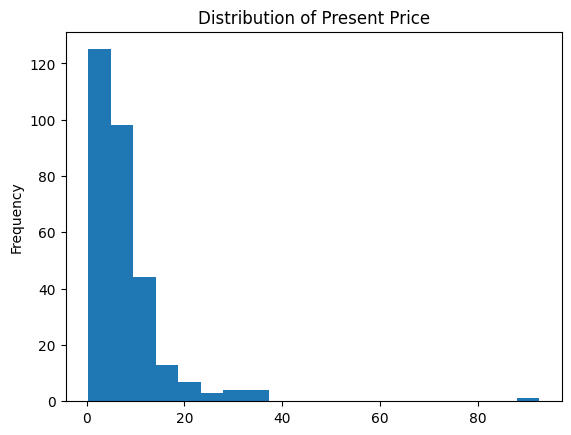

In [ ]:
df["Present_Price"].plot(kind="hist",bins=20,title="Distribution of Present Price")
plt.show()

In [ ]:
df.sort_values(["Present_Price"],ascending=False)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
86,land cruiser,2010,35.00,92.60,78000,Diesel,Dealer,Manual,0
64,fortuner,2017,33.00,36.23,6000,Diesel,Dealer,Automatic,0
59,fortuner,2014,19.99,35.96,41000,Diesel,Dealer,Automatic,0
62,fortuner,2014,18.75,35.96,78000,Diesel,Dealer,Automatic,0
63,fortuner,2015,23.50,35.96,47000,Diesel,Dealer,Automatic,0
...,...,...,...,...,...,...,...,...,...
187,Honda CB twister,2013,0.25,0.51,32000,Petrol,Individual,Manual,0
197,Honda CB twister,2010,0.16,0.51,33000,Petrol,Individual,Manual,0
181,Hero Splender Plus,2016,0.30,0.48,50000,Petrol,Individual,Manual,0
183,Bajaj Discover 100,2013,0.27,0.47,21000,Petrol,Individual,Manual,0


In [ ]:
df.columns


Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')

In [ ]:
df["Fuel_Type"].unique()

array(['Petrol', 'Diesel', 'CNG'], dtype=object)

In [ ]:
fuel_type_avg_price=df.groupby("Fuel_Type")["Present_Price"].mean()
fuel_type_avg_price

,Present_Price
Fuel_Type,
CNG,6.415000
Diesel,15.646034
Petrol,5.583556


In [ ]:
 fuel_type_avg_price.sort_values(ascending=True)

,Present_Price
Fuel_Type,
Petrol,5.583556
CNG,6.415000
Diesel,15.646034


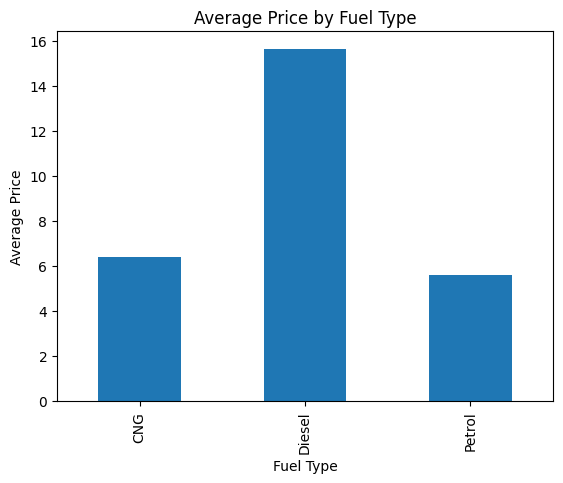

In [ ]:
fuel_type_avg_price.plot(kind="bar",title="Average Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Average Price")
plt.show()

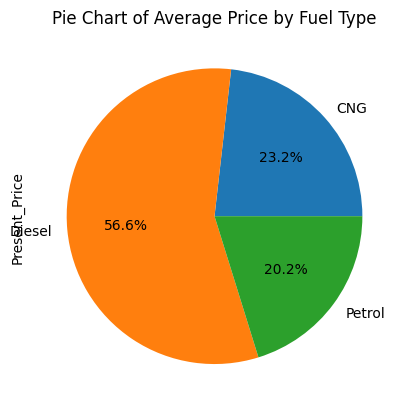

In [ ]:
fuel_type_avg_price.plot(kind="pie", autopct="%1.1f%%", title="Pie Chart of Average Price by Fuel Type")
plt.show()

Text(0, 0.5, 'Average Price')

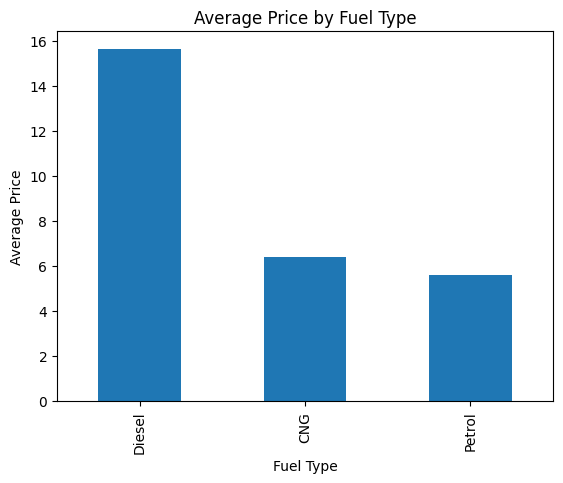

In [ ]:
fuel_type_avg_price.sort_values(ascending=False).plot(kind="bar",title="Average Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Average Price")

In [ ]:
transmission_counts=df["Transmission"].value_counts()
transmission_counts

,count
Transmission,
Manual,260
Automatic,39


In [ ]:
transmission_countsf=df["Fuel_Type"].value_counts()
transmission_countsf

,count
Fuel_Type,
Petrol,239
Diesel,58
CNG,2


In [ ]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')

In [ ]:
seller_type_group=df.groupby("Seller_Type")["Present_Price"].sum()
seller_type_group


,Present_Price
Seller_Type,
Dealer,2081.43
Individual,173.34


In [ ]:
year_average_kilometer=df.groupby("Year")["Kms_Driven"].mean()
year_average_kilometer

,Kms_Driven
Year,
2003,94500.000000
2004,135154.000000
2005,104294.000000
2006,87422.250000
2007,51000.000000
2008,112128.571429
2009,67820.500000
2010,60014.066667
2011,40327.368421


In [ ]:
fuel_type_tranmission_type=df.groupby(["Fuel_Type","Transmission"])["Selling_Price"].max()
fuel_type_tranmission_type

Fuel_Type  Transmission
CNG        Manual           3.25
Diesel     Automatic       33.00
           Manual          35.00
Petrol     Automatic       19.75
           Manual          17.00
Name: Selling_Price, dtype: float64

In [ ]:
fuel_type_tranmission_type.reset_index()

,Fuel_Type,Transmission,Selling_Price
0,CNG,Manual,3.25
1,Diesel,Automatic,33.00
2,Diesel,Manual,35.00
3,Petrol,Automatic,19.75
4,Petrol,Manual,17.00


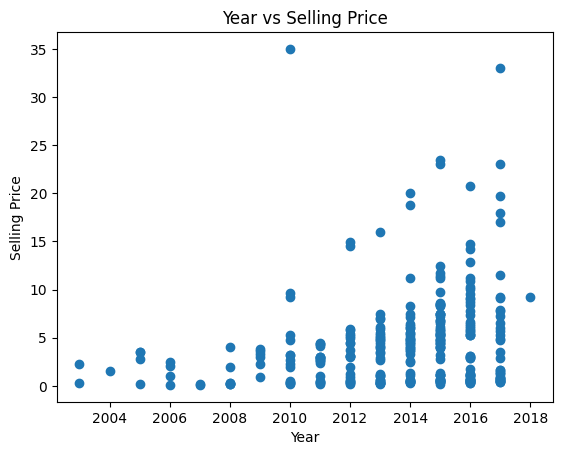

In [ ]:
 plt.scatter(df["Year"],df["Selling_Price"])
 plt.xlabel("Year")
 plt.ylabel("Selling Price")
 plt.title("Year vs Selling Price")
 plt.show()

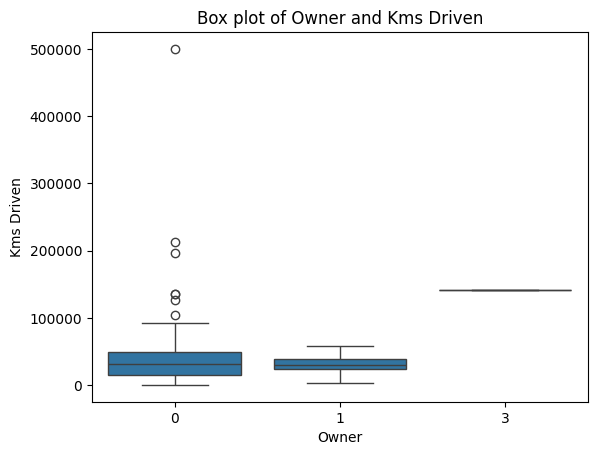

In [ ]:
sns.boxplot(x="Owner",y="Kms_Driven",data=df)
plt.title("Box plot of Owner and Kms Driven")
plt.xlabel("Owner")
plt.ylabel("Kms Driven")
plt.show()

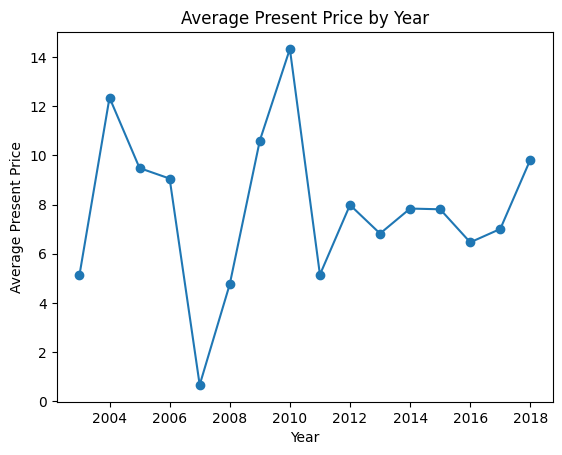

In [ ]:
plt.plot(df.groupby("Year")["Present_Price"].mean(),marker="o")
plt.xlabel("Year")
plt.ylabel("Average Present Price")
plt.title("Average Present Price by Year")
plt.show()

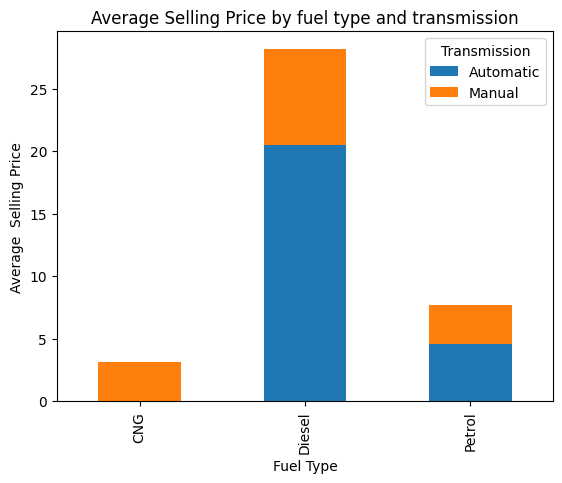

In [ ]:
 df.groupby(["Fuel_Type","Transmission"])["Selling_Price"].mean().unstack().plot(kind="bar",stacked=True)
 plt.xlabel("Fuel Type")
 plt.ylabel("Average  Selling Price")
 plt.title("Average Selling Price by fuel type and transmission")
 plt.show()

In [ ]:
df


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [ ]:
y=df["Selling_Price"]

In [ ]:
x=df[["Fuel_Type","Year","Kms_Driven","Owner","Transmission"]]

In [ ]:
x

,Fuel_Type,Year,Kms_Driven,Owner,Transmission
0,Petrol,2014,27000,0,Manual
1,Diesel,2013,43000,0,Manual
2,Petrol,2017,6900,0,Manual
3,Petrol,2011,5200,0,Manual
4,Diesel,2014,42450,0,Manual
...,...,...,...,...,...
296,Diesel,2016,33988,0,Manual
297,Petrol,2015,60000,0,Manual
298,Petrol,2009,87934,0,Manual
299,Diesel,2017,9000,0,Manual


In [ ]:
from sklearn import preprocessing
labelencoder = preprocessing.LabelEncoder()

In [ ]:
x["Fuel_Type"]=labelencoder.fit_transform(x["Fuel_Type"])
x["Transmission"]=labelencoder.fit_transform(x["Transmission"])



/tmp/ipykernel_2510/1675122627.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x["Fuel_Type"]=labelencoder.fit_transform(x["Fuel_Type"])
/tmp/ipykernel_2510/1675122627.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x["Transmission"]=labelencoder.fit_transform(x["Transmission"])


In [ ]:
x

,Fuel_Type,Year,Kms_Driven,Owner,Transmission,Transmisson
0,2,2014,27000,0,1,1
1,1,2013,43000,0,1,1
2,2,2017,6900,0,1,1
3,2,2011,5200,0,1,1
4,1,2014,42450,0,1,1
...,...,...,...,...,...,...
296,1,2016,33988,0,1,1
297,2,2015,60000,0,1,1
298,2,2009,87934,0,1,1
299,1,2017,9000,0,1,1


,Selling_Price
0,3.35
1,4.75
2,7.25
3,2.85
4,4.60
...,...
296,9.50
297,4.00
298,3.35
299,11.50


In [ ]:
x

,Fuel_Type,Year,Kms_Driven,Owner,Transmission,Transmisson
0,2,2014,27000,0,1,1
1,1,2013,43000,0,1,1
2,2,2017,6900,0,1,1
3,2,2011,5200,0,1,1
4,1,2014,42450,0,1,1
...,...,...,...,...,...,...
296,1,2016,33988,0,1,1
297,2,2015,60000,0,1,1
298,2,2009,87934,0,1,1
299,1,2017,9000,0,1,1


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaled_x_train=scaler.fit_transform(x_train)
scaled_x_test=scaler.fit_transform(x_test)

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
import numpy as np


In [ ]:
def modelresults(predictions):
  print("Mean Absolute Error is {}".format(mean_absolute_error(y_test,predictions)))
  print("Root Mean Squared Error is {}".format(np.sqrt(mean_squared_error(y_test,predictions))))

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
lr=LinearRegression()

In [ ]:
lr.fit(scaled_x_train,y_train)

LinearRegression()

In [ ]:
predslr=lr.predict(scaled_x_test)

In [ ]:
modelresults(predslr)

Mean Absolute Error is 2.550144943214257
Root Mean Squared Error is 3.296434619019728


In [ ]:
from sklearn.svm import SVR#(Support Vectore Machine Algorithm)
#tools used for supervised machine learning including classification,regression and outlier detection


In [ ]:
from sklearn.model_selection import GridSearchCV
#returns the best performing one

In [ ]:
svrmodel=SVR()

In [ ]:
param_gridsvr={"C" :[0.1,0.5], "kernel" : ["linear","rbf","poly"],"degree":[2,3,4]}

In [ ]:
gridsvr=GridSearchCV(svrmodel,param_gridsvr)

In [ ]:
gridsvr.fit(scaled_x_train,y_train)

GridSearchCV(estimator=SVR(),
             param_grid={'C': [0.1, 0.5], 'degree': [2, 3, 4],
                         'kernel': ['linear', 'rbf', 'poly']})

In [ ]:
gridsvr.best_params_

{'C': 0.1, 'degree': 2, 'kernel': 'linear'}

In [ ]:
predsgridsvr=gridsvr.predict(scaled_x_test)

In [ ]:
modelresults(predsgridsvr)

Mean Absolute Error is 2.1678131012643473
Root Mean Squared Error is 2.747445052137944
